In [1]:
using JLD2
using Printf, LaTeXStrings
import PyPlot
using JSON

In [2]:
SAVE_PLOTS = true

true

## Paper plot

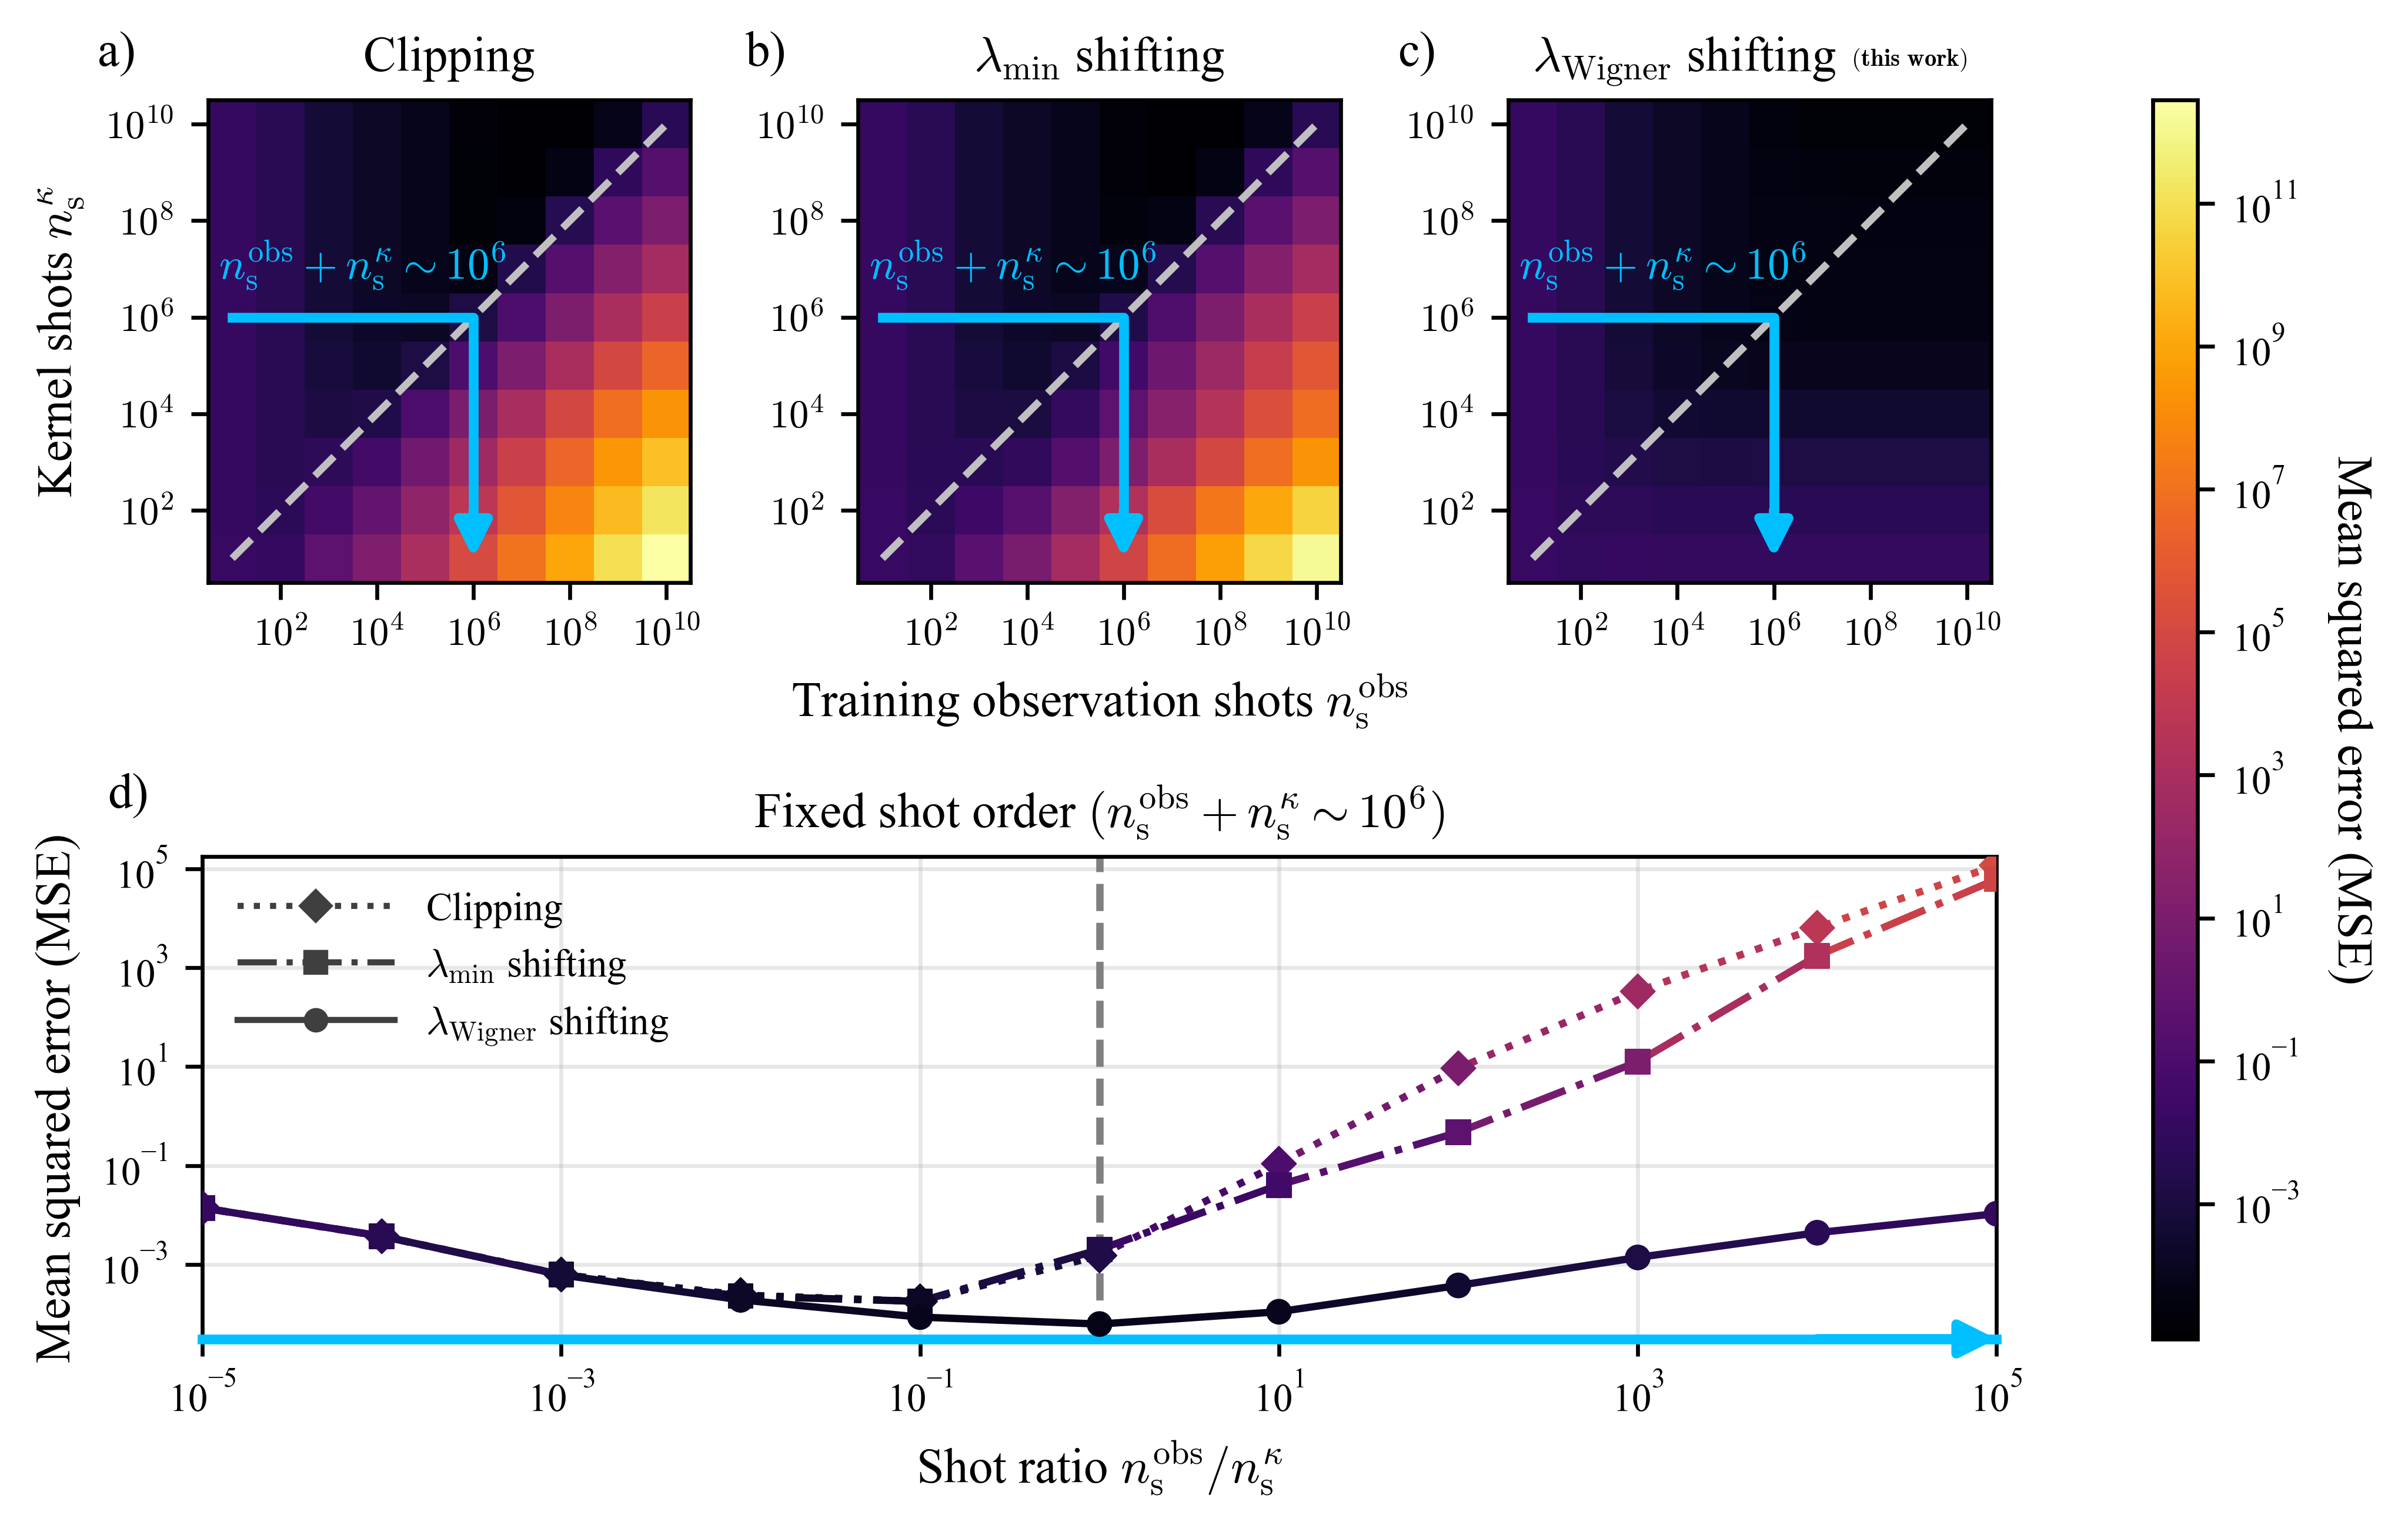

In [3]:
using PyPlot
using JSON
using Printf
using JLD2
using LaTeXStrings
using PyCall

width_inches = 6.92654  #* 0.45
height_inches = 2 / 0.45

BUDGET = 10.0^6

# 1. Plain text outside, math inside the $...$
obs_shots_label = L"Training observation shots $n_{\mathrm{s}}^{\mathrm{obs}}$"
ker_shots_label = L"Kernel shots $n_{\mathrm{s}}^{\kappa}$"
ratio_label = L"Shot ratio $n_{\mathrm{s}}^{\mathrm{obs}} / n_{\mathrm{s}}^{\kappa}$"

budget_str = @sprintf("10^{%d}", round(Int, log10(BUDGET)))

# 2. For the interpolation ones, keep the %$ syntax for the Julia variable, 
# but ensure the math bounding $...$ only wraps the equation part.
full_budget_title = L"Fixed shot order $(n_{\mathrm{s}}^{\mathrm{obs}} + n_{\mathrm{s}}^{\kappa} \sim %$(budget_str))$"
budget_title = L"$n_{\mathrm{s}}^{\mathrm{obs}} + n_{\mathrm{s}}^{\kappa} \sim %$(budget_str)$"

trim_label = "Clipping"
shift_label = L"$\lambda_{\mathrm{min}}$ shifting"
semi_label = L"$\lambda_{\mathrm{Wigner}}$ shifting"

# --- 1. Backend & Formatting Setup ---
plt.style.use("default")
plt.style.use("../../config/unified_plots.mplstyle")
plot_args = JSON.parsefile("../../config/unified_plots.json")
make_kwargs(dict) = Dict(Symbol(k) => v for (k, v) in dict)

# --- 2. Load Data ---
metric = "mse"
_ntp   = 10
n = 50
m = 2
data_semi  = load_object("../results/n$(n)_m$(m)_comparison_10_semicircle.jld2")
data_shift = load_object("../results/n$(n)_m$(m)_comparison_10_shift.jld2")
data_trim  = load_object("../results/n$(n)_m$(m)_comparison_10_trim.jld2")

mat_semi  = abs.(data_semi["metrics"][_ntp]["gp_$(metric)"])'
mat_shift = abs.(data_shift["metrics"][_ntp]["gp_$(metric)"])'
mat_trim  = abs.(data_trim["metrics"][_ntp]["gp_$(metric)"])'

shots_range_raw = 10.0 .^ (1:10)
shots_edges = 10.0 .^ (0.5:1:10.5)

# --- 3. Compute Global Limits & Colormap Setup ---
lo = min(minimum(mat_semi), minimum(mat_shift), minimum(mat_trim))
hi = max(maximum(mat_semi), maximum(mat_shift), maximum(mat_trim))
global_clims = (lo, hi)

cmap_name = "inferno"
slice_color = "deepskyblue"

mcolors = PyPlot.matplotlib.colors
log_norm = mcolors.LogNorm(vmin=lo, vmax=hi)
cmap_obj = plt.get_cmap(cmap_name)

# --- 4. Define the Discrete Fixed-Sum Path ---
min_ratio = 10.0^1 / (BUDGET - 10.0^1)
max_ratio = (BUDGET - 10.0^1) / 10.0^1

curve_ratios = 10.0 .^ range(log10(min_ratio), log10(max_ratio), length=500)
curve_x_raw = BUDGET .* curve_ratios ./ (curve_ratios .+ 1.0)
curve_y_raw = BUDGET ./ (curve_ratios .+ 1.0)

idx_x = clamp.(round.(Int, log10.(curve_x_raw)), 1, 10)
idx_y = clamp.(round.(Int, log10.(curve_y_raw)), 1, 10)

discrete_path = unique(tuple.(idx_x, idx_y))
discrete_obs_idx = [p[1] for p in discrete_path]
discrete_pred_idx = [p[2] for p in discrete_path]

path_x_raw = 10.0 .^ discrete_obs_idx
path_y_raw = 10.0 .^ discrete_pred_idx
discrete_ratios = path_x_raw ./ path_y_raw

slice_semi  = [mat_semi[discrete_pred_idx[i], discrete_obs_idx[i]] for i in 1:length(discrete_path)]
slice_shift = [mat_shift[discrete_pred_idx[i], discrete_obs_idx[i]] for i in 1:length(discrete_path)]
slice_trim  = [mat_trim[discrete_pred_idx[i], discrete_obs_idx[i]] for i in 1:length(discrete_path)]


# ======================================================================
# --- 5. Figure & Layout Generation (PURE JULIA GRIDSPEC) ---
# ======================================================================
fig = plt.figure(figsize=(width_inches, height_inches))

# 2 rows, 4 columns.
# width_ratios: 3 equal columns for heatmaps, 1 narrow column (0.09) for the colorbar.
gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1, 1, 1, 0.09], height_ratios=[1, 1])

# Fetch Python's native slice() function to bypass Julia's UnitRange
pyslice = pybuiltin("slice")

# FIX: Use `get()` for ALL indexing to bypass PyCall's automatic "-1" translation.
# Top Row (Row 0 in Python): Columns 0, 1, and 2
ax_trim  = fig.add_subplot(get(gs, (0, 0)))
ax_shift = fig.add_subplot(get(gs, (0, 1)))
ax_semi  = fig.add_subplot(get(gs, (0, 2)))

# Bottom Row (Row 1): Line plot spanning columns 0, 1, and 2. 
ax_slice = fig.add_subplot(get(gs, (1, pyslice(0, 3))))

# Colorbar Axis: Spanning all rows (pyslice(nothing) == ':'), in column 3.
cax = fig.add_subplot(get(gs, (pyslice(nothing), 3)))

fig.subplots_adjust(wspace=0.0, hspace=0.0)


# --- 6. Heatmap Plotting Function ---
tick_vals = 10.0 .^ (2:2:10)
tick_labs = [LaTeXString("\$10^{$(i)}\$") for i in 2:2:10]

function plot_heatmap(ax, M, title; show_xlabel=false, show_ylabel=false)
    pc = ax.pcolormesh(shots_edges, shots_edges, M, cmap=cmap_name, norm=log_norm, rasterized=true)
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(10.0^0.5, 10.0^10.5)
    ax.set_ylim(10.0^0.5, 10.0^10.5)
    ax.set_title(title)

    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labs)
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labs)

    if show_xlabel
        ax.set_xlabel(obs_shots_label)
    end
    if show_ylabel
        ax.set_ylabel(ker_shots_label)
    end

    ax.plot(shots_range_raw, shots_range_raw, linestyle="--", color="silver", lw=1.5)
    
    # Plot line up to the second-to-last point
    ax.plot(path_x_raw[1:end-1], path_y_raw[1:end-1], linestyle="-", color=slice_color, lw=2.0)

    
    ax.annotate("", xy=(path_x_raw[end], path_y_raw[end]), 
                xytext=(path_x_raw[end-1], path_y_raw[end-1]),
                arrowprops=Dict("arrowstyle" => "-|>", "color" => slice_color, "lw" => 2.0, 
                                "shrinkA" => 0, "shrinkB" => 0, "mutation_scale" => 15,
                                ))

    anno_x = path_x_raw[max(1, length(path_x_raw) ÷ 2 - 2)] * 5 
    anno_y = BUDGET * 3.5
    ax.text(anno_x, anno_y, budget_title, color=slice_color, ha="center", va="bottom", fontsize=9)
end

plot_heatmap(ax_trim, mat_trim, trim_label, show_ylabel=true)
plot_heatmap(ax_shift, mat_shift, shift_label, show_xlabel=true)
plot_heatmap(ax_semi, mat_semi, semi_label * L" $_{^{\mathbf{(this\ work)}}}$")

# --- 7. Plot Panel B (Line Plot) ---
x_min, x_max = minimum(discrete_ratios), maximum(discrete_ratios)
y_data_min = minimum([minimum(slice_semi), minimum(slice_shift), minimum(slice_trim)])
y_data_max = maximum([maximum(slice_semi), maximum(slice_shift), maximum(slice_trim)])

ax_slice.set_xscale("log")
ax_slice.set_yscale("log")
ax_slice.set_xlim(x_min, x_max)
ax_slice.set_ylim(y_data_min * 0.5, y_data_max * 1.5)
ax_slice.set_xlabel(ratio_label)
ax_slice.set_ylabel(plot_args["benchmarking"]["axes"]["ylabel_mse"])
ax_slice.set_title(full_budget_title)

ax_slice.grid(true; make_kwargs(plot_args["benchmarking"]["axes"]["grid_major"])...)
ax_slice.grid(true; make_kwargs(plot_args["benchmarking"]["axes"]["grid_minor"])...)
ax_slice.axvline(1.0, color="gray", linestyle="--", lw=1.5)

function plot_colored_segments(ax, x, y, label, marker, linestyle)
    x_rev = reverse(x)
    y_rev = reverse(y)

    ax.scatter(x_rev, y_rev, c=y_rev, cmap=cmap_name, norm=log_norm, 
               marker=marker, s=25, linewidths=0.25, edgecolors="face", zorder=3)

    for i in 1:length(x_rev)-1
        c_val = (y_rev[i] + y_rev[i+1]) / 2.0
        c = cmap_obj(log_norm(c_val))
        ax.plot([x_rev[i], x_rev[i+1]], [y_rev[i], y_rev[i+1]], color=c, linestyle=linestyle, lw=1.5)
    end

    ax.plot([], [], color="#3f3f3f", marker=marker, linestyle=linestyle, markersize=4, lw=1.25, label=label)
end

plot_colored_segments(ax_slice, discrete_ratios, slice_trim, trim_label, "D", ":")   
plot_colored_segments(ax_slice, discrete_ratios, slice_shift, shift_label, "s", "-.") 
plot_colored_segments(ax_slice, discrete_ratios, slice_semi, semi_label, "o", "-")

ax_slice.annotate("", xy=(x_max, y_data_min * 0.5), xytext=(x_max * 0.1, y_data_min * 0.5),
                  arrowprops=Dict("arrowstyle" => "-|>", "color" => slice_color, "lw" => 2.0,
                                  "shrinkA" => 0, "shrinkB" => 0, "mutation_scale" => 15))

ax_slice.legend(loc="upper left", handlelength=4, frameon=false)

ax_slice.spines["bottom"].set_color(slice_color)
ax_slice.spines["bottom"].set_linewidth(2.0)
ax_slice.spines["bottom"].set_linestyle("-")

# --- 8. Populate Colorbar ---
sm = PyPlot.matplotlib.cm.ScalarMappable(norm=log_norm, cmap=cmap_name)
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.minorticks_on()
cbar.solids.set_rasterized(true)
cbar.set_label(plot_args["benchmarking"]["axes"]["ylabel_mse"], rotation=270, labelpad=15)


# --- Add Panel Labels ---
# Get the font size from your loaded style sheet
label_font_size = PyPlot.matplotlib.rcParams["axes.labelsize"]

# Use a dictionary to easily apply the exact same formatting to all labels
label_kwargs = Dict(
    "fontsize" => label_font_size,
    #"fontweight" => "bold",
    "va" => "bottom",      # Vertical alignment: anchor to the bottom of the text
    "ha" => "right",       # Horizontal alignment: anchor to the right of the text
    "in_layout" => false   # Layout engines will completely ignore this text!
)

# Top row (Heatmaps)
# x = -0.15 pushes it 15% to the left of the y-axis. y = 1.05 pushes it 5% above the top spine.
ax_trim.text(-0.15, 1.05, "a)", transform=ax_trim.transAxes; make_kwargs(label_kwargs)...)
ax_shift.text(-0.15, 1.05, "b)", transform=ax_shift.transAxes; make_kwargs(label_kwargs)...)
ax_semi.text(-0.15, 1.05, "c)", transform=ax_semi.transAxes; make_kwargs(label_kwargs)...)

# Bottom row (Line plot)
# Because ax_slice is physically 3 times wider than the heatmaps, a 15% shift (-0.15) 
# would push it way too far to the left. We reduce it to -0.05 to match the physical distance.
ax_slice.text(-0.03, 1.08, "d)", transform=ax_slice.transAxes; make_kwargs(label_kwargs)...)

# --- 9. Save ---
if @isdefined(SAVE_PLOTS) && SAVE_PLOTS 
    isdir("../plots") || mkdir("../plots")
    # No bbox_inches="tight" needed anymore since we control the exact canvas margins!
    fig.savefig("../plots/n$(n)_m$(m)_ntp$(_ntp)_bench_psd.pdf")
end

display(fig)